# 2025 project

This notebook contains the assignment for part 1 (ECG) of the project of BDP of 2025 in Python.

## General remarks

First and foremost: **read the assignment description carefully**. There is plenty of information in the description that is relevant for both the implementation and oral defence. Your notebooks should produce all the desired plots/output with one click of the ‘run’-button! Document your code to facilitate debugging, reuse, and evaluation (in case of problems). We have provided code skeletons for both parts of the project to get you started. We strongly encourage you to use them and to keep the general structure of the skeleton intact.

You must generate all plots, tables... that are asked for in the Deliverables. Make sure that all plots are intelligible, contain proper axis labels, have titles...You are allowed and encouraged to reuse your code of the exercise sessions, however, we repeat that it is forbidden to share code between different teams and that automatically generated code should be properly referenced. We further refer to the rules on code/software plagiarism on Toledo.

Even if you're stuck on any part of the assignment, you can still proceed to the next parts of the assignment.

## Evaluation

You can complete the assignment alone or in a group of 2. You will need to submit (as a team):


*   your full Python code,
*   a filled-out version of the attached overview sheet.

Please upload your code and overview sheet on Toledo at the latest on **Saturday December 13th, at 23:59**. Do **not** include data and packages or scripts we provided, but only the files you wrote or modified. Make sure that your script produces all plots and results required in the assignment, as listed in the ‘Deliverables’. The exemplary interpretation questions mentioned in the assignment reflect the type of questions that might be asked on the oral evaluation.

The project will be evaluated *individually* during the oral examination on Wednesday/Thursday the 17th/18th of December. You will be asked questions about all parts of the project. Make sure you understand all methods that you use, even if you did not implement the code for that method yourself.



## 1. ECG-based identification

### Background

Robust identification is crucial to regulate who has access to a vault, a laptop, sensitive data... While passwords used to be the go-to method to identify a person, it becomes more and more apparent that they are too vulnerable to human weaknesses, such as people re-using the same password
everywhere or using passwords that are easily guessable. The speed and availability of biometrics such as iris, face and fingerprint scans have therefore provided a robust alternative for identification. However, these biometrics are all relatively simple to recreate (called spoofing) without the subject noticing this [1].

To combat these issues, ECG has gained a lot of attention in recent years as a biometric for identification. Similar to our face and fingerprint, our ECG is highly individual. Furthermore, it is much harder to recreate someone’s ECG than, e.g., someone’s face, since 1) it is much harder to record someone’s ECG without them noticing than it is taking pictures of them and 2) ECG is a
time signal, which is much harder to recreate than a static signal such as a mask of someone’s face [1]. Finally, the recent inclusion of ECG sensors in (nearly) all smartwatches made ECG broadly available as a biometric.

[1] M. Ingale, R. Cordeiro, S. Thentu, Y. Park, and N. Karimian, “ECG biometric authentication: A comparative analysis,” *IEEE Access*, vol. 8, pp. 117 853–117 866, 2020

In [9]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import scipy
import pywt
from matplotlib.axes import Axes
from scipy.fft import fft, ifft, fftshift
from typing import List, Optional, Union
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import random
import scipy
from scipy.signal import welch
from collections import Counter
import pandas as pd
from sklearn.preprocessing import StandardScaler

### 1.1 Data exploration

We simulated the real-life scenario where different people attempt to gain access to a single device by allowing the device to briefly measure their ECG (only a single heartbeat was measured at once). The device continuously measures a single channel of ECG, no matter whether someone is actually
touching the sensor or not. You thus get a single continuous signal that contains the ECG of multiple different people. The measured signal is approximately 10 min long and sampled at fs = 200 Hz. In total, five different subjects attempted to gain access to the device multiple times in a random
order. Subjects 1,2,4 and 5 are completely healthy, while Subject 3 suffers from valvular heart disease (meaning that one or more heart valves don’t open or close properly).

We already cleaned up the signal such that long pauses where the sensor did not measure a single heartbeat, are removed. Furthermore, we also removed heartbeats that were only partially measured (i.e. where a subject started measuring their ECG in the middle of the heartbeat). Because each subject only measured their ECG for a single heartbeat, there is no guarantee at all that two
consecutive heartbeats come from the same person, no matter how close they are to each other.

Every sample in the signal also has a corresponding label, indicating which of the five subjects was touching the sensor at each moment in time. **These labels only serve to evaluate the performance of your algorithm and to explore the data (when we explicitly ask you to do so). The identification algorithm itself must be completely unsupervised.**

This ECG data was originally recorded in the Physikalish-Technische Bundesanstalt, Berlin [2] and made publically available on Physionet. The signals were adapted for use in this project.

[2] R. Bousseljot, D. Kreiseler, and A. Schnabel, “Nutzung der EKG-Signaldatenbank CARDIODAT der PTB über das Internet,” *Biomedizinische Technik / Biomedical Engineering*, vol. 40, no. s1, pp. 317–318, jan 1995.

In [10]:
signal = np.load("ecg_signal.npz")
print(signal.keys())
ecg = signal['ecg']
print(f"The ECG shape is {ecg.shape}.")
fs = int(signal['fs'])
print(type(fs))
print(f"The sampling frequency is {fs} Hz.")
labels = signal['labels']
print(f"The labels' shape is {labels.shape}.")

KeysView(NpzFile 'ecg_signal.npz' with keys: ecg, fs, labels)
The ECG shape is (121006,).
<class 'int'>
The sampling frequency is 200 Hz.
The labels' shape is (121006,).


Plot a random window of 20s of the raw ECG signal. Inspect which noise sources have infected the signal (if any). The noise is stationary, so it suffices to inspect a single segment to identify the noise sources.

In [11]:
def plot_ecg_time(
    signal: npt.NDArray[np.float64],
    fs: Union[int, float],
    ax: Axes,
    label: Optional[str] = None,
    linewidth: Union[int, float] = 1,
) -> None:
    n = len(signal)
    t = n/fs
    time = np.linspace(0, t, n)
    ax.plot(time, signal, label=label, linewidth=linewidth)

start sample: 70801
end sample: 74801


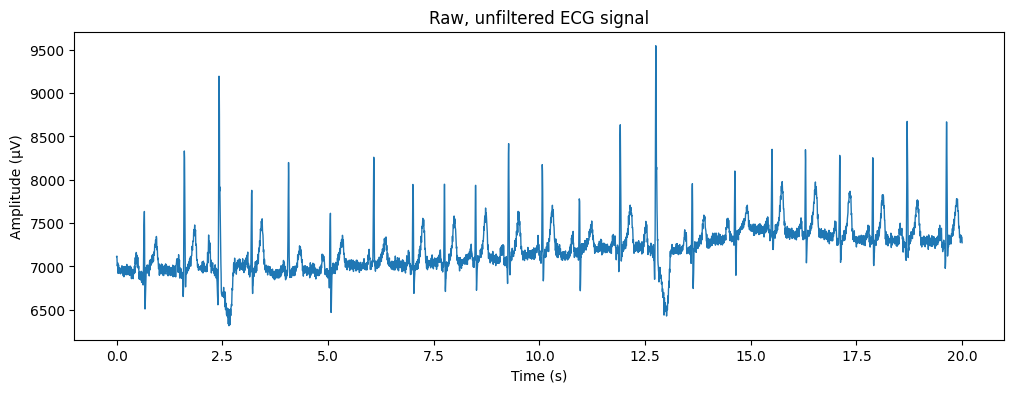

In [12]:
# plot 20 s
fig, ax = plt.subplots(figsize=(12, 4))

duration = 20
window_length = int(duration * fs)

max_start_sample = len(ecg) - window_length

start_sample = random.randint(0, max_start_sample)
end_sample = start_sample + window_length
print("start sample:", start_sample)
print("end sample:", end_sample)

ec_window = ecg[start_sample:end_sample]

plot_ecg_time(ec_window, fs, ax)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title("Raw, unfiltered ECG signal")
plt.show()

#### 1.1.1 Additional questions

*   Which noise sources do you see? Why?

The artefacts I see in the signal above are baseline drift, powerline noise, and muscle-movement noise. The baseline drifts up and down because each person touches the sensor with slightly different pressure or skin contact, so the whole signal shifts as they come and go. There is also a 50 Hz electrical hum from the environment, which is powerline noise when recording near lights, chargers, or other electronics. On top of that, the high-frequency activity might be coming from tiny finger movements and muscle tension.

------------------------------------------------


#### 1.1.2 Delivarables

*   A plot containing 20s of the raw, unfiltered ECG signal.

### 1.2 Wiener filter

Next, we wish to remove as much noise as possible using a Wiener filter. Closely follow the steps below (note that the methodology to compute some parts of the Wiener filter may differ from Exercise Session 2).

#### 1.2.1 Template estimation

Detect all R-peaks in the ECG signal using the Pan-Tompkins algorithm. Use these R-peak locations to estimate the average PQRST-complex in the signal. You can assume that each PQRST-complex starts 0.3 s before the R-peak and ends 0.4 s after the R-peak. Make sure that you align the R-peaks of all PQRST-complexes before averaging them, such that the average PQRST-complex is 0.7s long.

Next, you can consider all samples that are not part of any PQRST-complex (i.e. all samples that are 0.4 s after the last and 0.3 s before the next R-peak) as noise. Concatenate all noise segments, such that they form a single noise signal. You can ignore the slight discontinuities that may appear between two noise segments. Verify that there are indeed no PQRST-complexes left in your noise signal.

In [13]:
def pan_tompkins(ecg_input, show=True, factor_threshold : float=1):

  # plot raw ecg
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(ecg_input, fs, ax)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title("Raw, unfiltered ECG signal")
    plt.show()

  # low-pass filter - 11Hz
  b, a = scipy.signal.butter(4, 11/(fs/2), 'low')
  ecg_lp = scipy.signal.filtfilt(b, a, ecg_input)

  # plot low-pass filtered signal
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(ecg_lp, fs, ax)
    ax.set_title("Low-pass filtered ECG")
    plt.show()

  # high-pass filter
  b, a = scipy.signal.butter(4, 5/(fs/2), 'high')
  ecg_bp  = scipy.signal.filtfilt(b, a, ecg_lp)

  # plot high-pass filtered signal
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(ecg_bp , fs, ax)
    ax.set_title("Band-pass filtered ECG")
    plt.show()

  # derivative
  # y[n] = (1/8) * (2x[n] + x[n-1] - x[n-3] - 2x[n-4])
  deriv_kernel = np.array([2, 1, 0, -1, -2]) / 8
  ecg_deriv = scipy.signal.lfilter(deriv_kernel, 1, ecg_bp)

  # plot derivative
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(ecg_deriv, fs, ax)
    ax.set_title("Derivative of ECG")
    plt.show()

  # squaring
  ecg_squared = ecg_deriv ** 2

  # plot squared
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(ecg_squared, fs, ax)
    ax.set_title("Squared signal")
    plt.show()

  # integration
  M = int(0.15 * fs)    # ~150 ms window, N=30
  mwa = np.convolve(ecg_squared, np.ones(M)/M, mode='same')

  # plot integration
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(mwa, fs, ax)
    ax.set_title("Moving Window Integration")
    plt.show()

  # find peaks on the integrated signal
  threshold = factor_threshold * np.mean(mwa)
  candidate_peaks, _ = scipy.signal.find_peaks(
        mwa,
        height=threshold,
        distance=int(0.25 * fs)   # min distance between beats ~250 ms -> 240 bpm max
    )

  # threshold peaks --> height=threshold in find_peaks

  # plot peaks
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(mwa, fs, ax)
    ax.plot(candidate_peaks / fs, mwa[candidate_peaks], 'ro', markersize=4)
    ax.set_title("Peaks detected on integrated signal")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (a.u.)")
    plt.show()

  # group delay

  # local search + lag correction
  refined_peaks = []
  search_win = int(0.1 * fs)  # +-100 ms

  for p in candidate_peaks:
      start = max(p - search_win, 0)
      end = min(p + search_win, len(ecg_bp))

      # find true R-peak as local maximum in band-passed ECG
      true_r = np.argmax(ecg_bp[start:end]) + start
      refined_peaks.append(true_r)

  refined_peaks = np.array(refined_peaks)

  # plot on original signal
  if show:
      fig, ax = plt.subplots()
      plot_ecg_time(ecg_input, fs, ax)
      ax.plot(refined_peaks / fs, ecg_input[refined_peaks], 'ro')
      ax.set_title("Detected R-peaks on raw ECG")
      ax.set_xlabel("Time (s)")
      ax.set_ylabel("Amplitude (µV)")
      plt.show()

  return refined_peaks

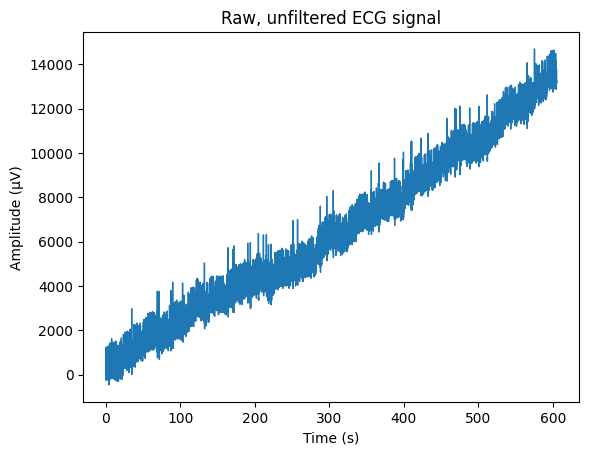

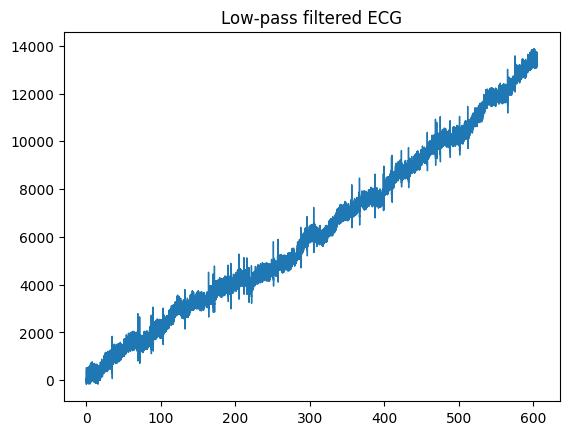

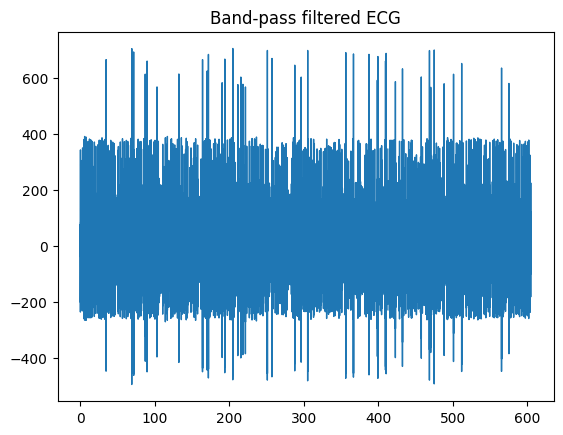

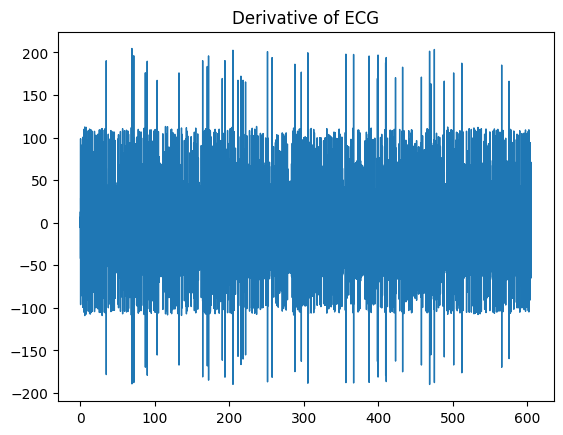

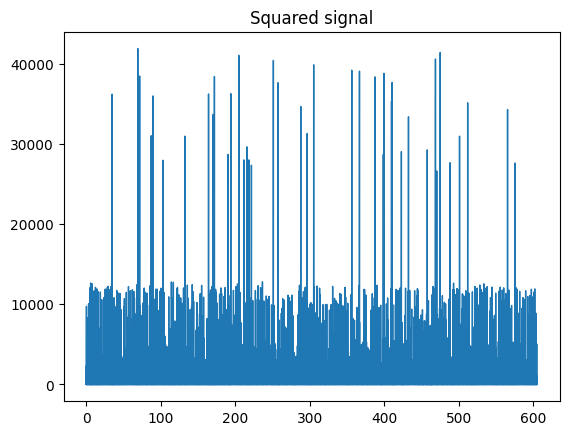

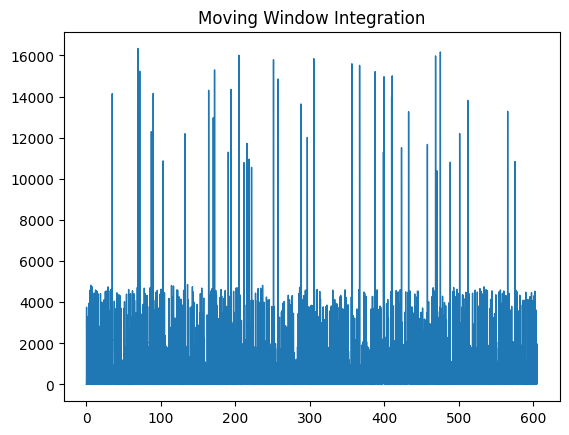

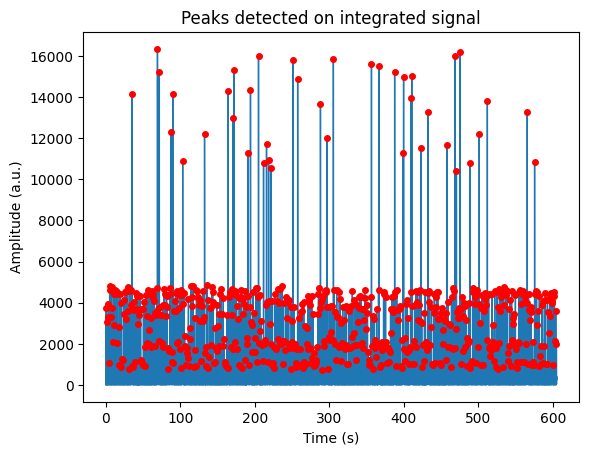

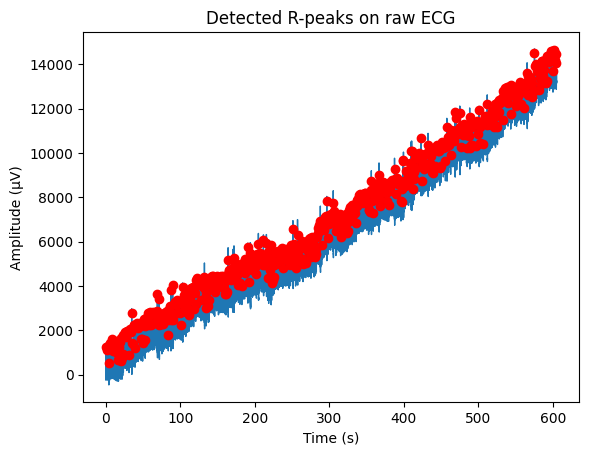

Number of detected peaks: 679


In [14]:
peaks_OG = pan_tompkins(ecg, show=True)
print("Number of detected peaks:", len(peaks_OG))

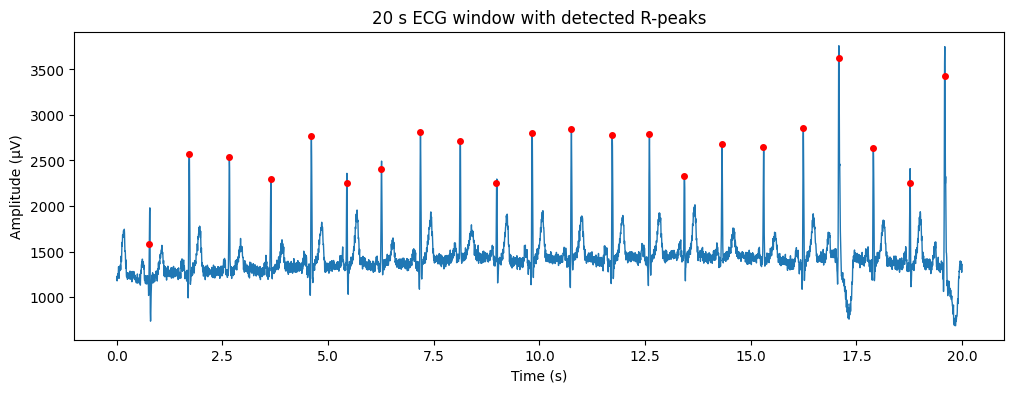

In [15]:
# Random 20s window to check how the algorithm predicts peaks
rng = np.random.default_rng(seed=42)

duration = 20
window_length = int(duration * fs)

start = rng.integers(0, len(ecg) - window_length)
end = start + window_length

ecg_win = ecg[start:end]
peaks = peaks_OG

peaks_win = peaks[(peaks >= start) & (peaks < end)] - start

fig, ax = plt.subplots(figsize=(12, 4))
plot_ecg_time(ecg_win, fs, ax)
ax.plot(peaks_win / fs, ecg_win[peaks_win], 'ro', markersize=4)
ax.set_title("20 s ECG window with detected R-peaks")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
plt.show()

In [16]:
def segment_pqrst_and_noise(signal, peaks, fs):
    """
    Segment a biomedical signal into PQRST complexes and noise.

    Parameters
    ----------
    signal : np.ndarray
        1D array of the biomedical signal (e.g., ECG).
    peaks : array_like
        Array of R-peak indices (in samples).
    fs : float
        Sampling frequency in Hz.

    Returns
    -------
    pqrst_segments : list of np.ndarray
        List of signal segments corresponding to each PQRST complex.
    noise_segments : list of np.ndarray List of signal segments between PQRST complexes (noise).
    """
    pqrst_segments = []
    noise_segments = []

    pre = int(0.3 * fs)
    post = int(0.4 * fs)
    expected_len = pre + post

    N = len(signal)

    peaks = np.sort(peaks)

    # extract PQRS segments
    pqrst_ranges = [] # to keep track of used intervals

    for p in peaks:
        start = p - pre
        end = p + post

        if start < 0 or end > N:
            continue  # skip incomplete segment

        seg = signal[start:end]
        if len(seg) == expected_len:   # sanity check
            pqrst_segments.append(seg)
            pqrst_ranges.append((start, end))

    # extract noise segments between the complexes
    for i in range(len(pqrst_ranges) - 1):
      _, end_prev = pqrst_ranges[i]
      start_next, _ = pqrst_ranges[i + 1]

      if start_next > end_prev:
          noise_segments.append(signal[end_prev:start_next])

    return pqrst_segments, noise_segments



In [17]:
# pqrst_segments, noise_segments = segment_pqrst_and_noise(...) arguments fixed
pqrst_segments, noise_segments = segment_pqrst_and_noise(ecg, peaks_OG, fs)

# concatenate the noise segments
noise_cts = np.concatenate(noise_segments)

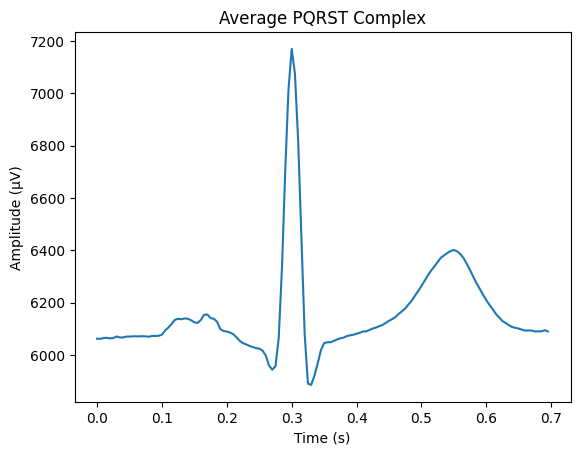

In [18]:
# compute and plot avg signal
pqrst_matrix = np.stack(pqrst_segments, axis=0)
avg_pqrst = np.mean(pqrst_matrix, axis=0)

fig, ax = plt.subplots()
t = np.arange(len(avg_pqrst)) / fs
ax.plot(t, avg_pqrst)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title("Average PQRST Complex")
plt.show()

#### 1.2.2 Create and apply the Wiener filter

Use the average PQRST-complex and the noise signal to create the Wiener filter. Make sure you use an adequate method to estimate the PSD’s necessary for the Wiener filter. Think carefully about the length of the Wiener filter. You can then use the provided wola_filt.m (or any alternative you prefer) to filter the original noisy ECG signal.

If you deem the Wiener filtering insufficient (or do not manage to compute it), you can add an additional Butterworth filter to further clean the signal.

After filtering, recompute the R-peak locations with the Pan-Tompkins algorithm if you think this is necessary. Do you get the same number of R-peaks? Why (not)?

In [19]:
def wiener_filter(d, n, Li=256):
    """
    Wiener filter using Welch PSD estimation.

    Parameters
    ----------
    d : np.ndarray
        Average PQRST complex (desired signal model).
    n : np.ndarray or list of np.ndarray
        Noise-only signal (concatenated or list of segments).
    fs : float
        Sampling frequency.
    Li : int
        FFT / filter length (must be even).

    Returns
    -------
    Wf : np.ndarray
        Wiener filter (frequency domain, two-sided).
    wt : np.ndarray
        Wiener filter impulse response (time domain).
    L : int
        Filter length.
    Sd : np.ndarray
        PSD of desired signal (two-sided).
    Sn : np.ndarray
        PSD of noise (two-sided).
    """

    d = d - np.mean(d)
    n = n - np.mean(n)

    L = Li
    if L % 2 != 0:
        L += 1

    # we will estimate PSD using welch
    # nperseg should be less than or equal to nfft (which is L)
    nperseg_welch = min(len(d), L // 2)
    noverlap_welch = nperseg_welch // 2 # by def

    # PSD of desired signal
    f_welch, Sd = welch(
        d,
        fs=fs,
        window="hann",
        nperseg=nperseg_welch,
        noverlap=noverlap_welch,
        nfft=L,
        return_onesided=False,
        scaling="density"
    )

    # PSD of noise
    _, Sn = welch(
        n,
        fs=fs,
        window="hann",
        nperseg=nperseg_welch,
        noverlap=noverlap_welch,
        nfft=L,
        return_onesided=False,
        scaling="density"
    )

    eps = 1e-12
    Wf = Sd / (Sd + Sn + eps)

    # the time-domain impulse response
    wt = np.real(np.fft.ifft(Wf))

    return Wf, wt, L, Sd, Sn

In [20]:
def wola_filt(x, H):
    """
    WOLA_FILT implements Weighted Overlap-Add Filtering, for sliding window
    filtering of long signals.

    Parameters
    ----------
    x : matrix with input signals to be filtered (samples,) or (samples x variables)
    H : filter in frequency domain (frequencies,) or (frequencies x 1)

    Returns
    -------
    y : matrix with filtered output signals (samples,) or (samples x variables)
    """

    # Initialize
    # Get the length of the signals and the nr of signals
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    sig_length, nsigs = x.shape
    # Get the FT length ( = filter length)
    L = len(H)
    # Check if it is an even number
    assert L % 2 == 0, "Filter length must be even"
    # Get the window length
    M = 1 * L
    assert M <= L, "Window length must be <= filter length"
    # Get the window shift (50% of the window length)
    sh = round(M / 2)
    # Get the number of windows
    nw = int(np.floor((sig_length - L) / sh) + 1)
    # Create the window function
    win = 'hann'
    w = scipy.signal.windows.hann(M)
    w = np.sqrt(w)
    # Apply zero-padding if the FFT length and window length differ
    if L > M:
        w = np.concatenate([w, np.zeros(L - M)])  # pad with zeros

    # Analysis + filtering + synthesis
    # Pre-allocate
    y = np.zeros(((nw - 1) * sh + L, nsigs))
    # Loop over the nr of windows
    for ii in range(nw):
        # Define the beginning and ending of the window
        start = ii * sh
        stop = start + L
        # Analysis
        x_window = x[start:stop, :]
        x_weighted = w.reshape(-1, 1) * x_window
        X = fft(x_weighted, axis=0)
        # Filtering
        Y = X * H.reshape(-1, 1)
        # Synthesis
        y_window = np.real(ifft(Y, axis=0))
        y_weighted = w.reshape(-1, 1) * y_window
        y[start:stop, :] = y[start:stop, :] + y_weighted

    # Pad the output if necessary, to match the input data length
    if y.shape[0] < sig_length:
        y = np.vstack([y, np.zeros((sig_length - y.shape[0], nsigs))])
    return y

In [21]:
# Pass the ECG signal to wiener filter
Wf, wt, L, Sd, Sn = wiener_filter(avg_pqrst, noise_cts, Li=256)
sig_wi = wola_filt(ecg, Wf).flatten()

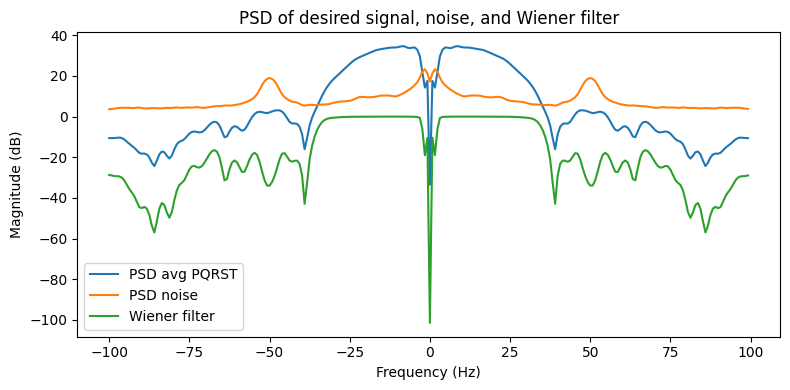

In [22]:
# Plots that show the PSD of the average PQRST-complex, the PSD of the noise and the transfer function of the Wiener filter (all in dB).
f = np.fft.fftshift(np.fft.fftfreq(L, 1/fs))

Sd_shift = np.fft.fftshift(Sd)
Sn_shift = np.fft.fftshift(Sn)
Wf_shift = np.fft.fftshift(np.abs(Wf))

eps = 1e-12

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(f, 10*np.log10(Sd_shift + eps), label="PSD avg PQRST")
ax.plot(f, 10*np.log10(Sn_shift + eps), label="PSD noise")
ax.plot(f, 20*np.log10(Wf_shift + eps), label="Wiener filter")

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("PSD of desired signal, noise, and Wiener filter")
ax.legend()
plt.tight_layout()
plt.show()



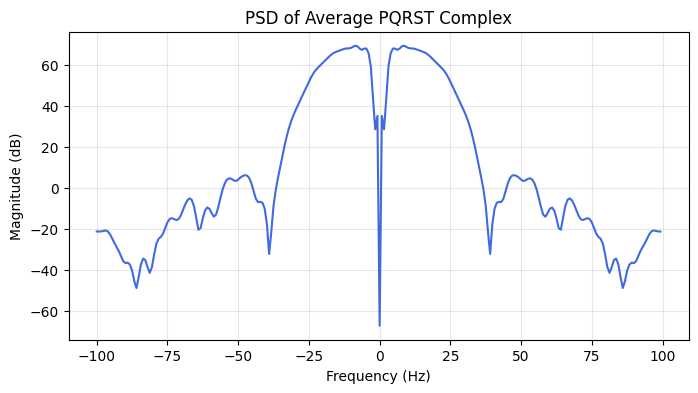

In [23]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(f, 20*np.log10(Sd_shift + eps), color='royalblue')
ax.set_title("PSD of Average PQRST Complex")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.grid(True, alpha=0.3)
plt.show()


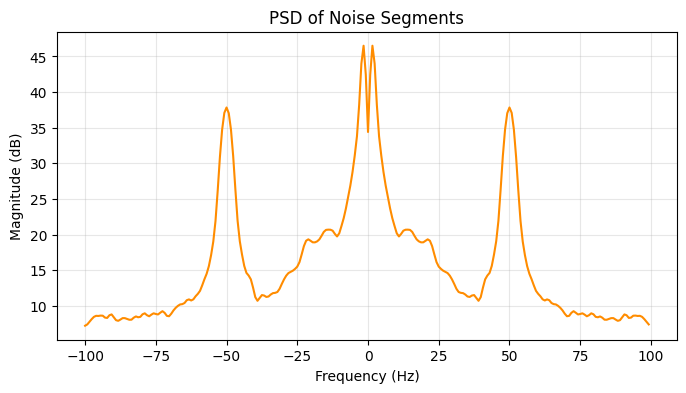

In [24]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(f, 20*np.log10(Sn_shift + eps), color='darkorange')
ax.set_title("PSD of Noise Segments")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.grid(True, alpha=0.3)
plt.show()

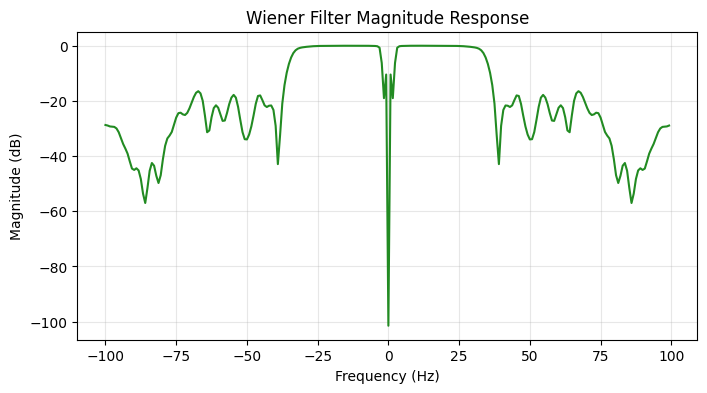

In [25]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(f, 20*np.log10(Wf_shift + eps), color='forestgreen')
ax.set_title("Wiener Filter Magnitude Response")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.grid(True, alpha=0.3)
plt.show()

In [26]:
# If necessary, recompute the R-peak locations with the Pan-Tompkins algorithm
peaks_raw = pan_tompkins(ecg, show=False)
peaks_filt = pan_tompkins(sig_wi, show=False)

print("Number of R-peaks (raw):", len(peaks_raw))
print("Number of R-peaks (filtered):", len(peaks_filt))

Number of R-peaks (raw): 679
Number of R-peaks (filtered): 676


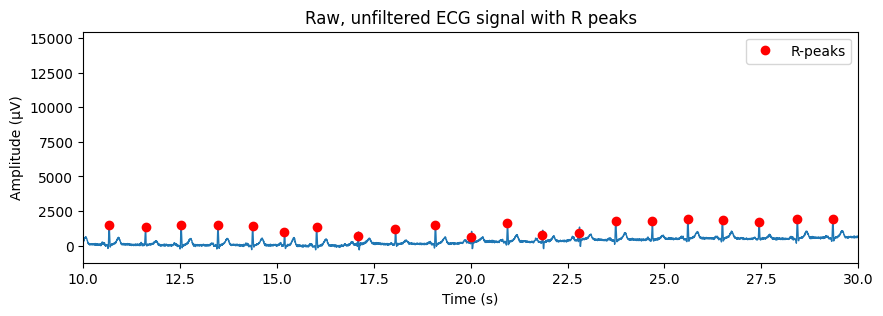

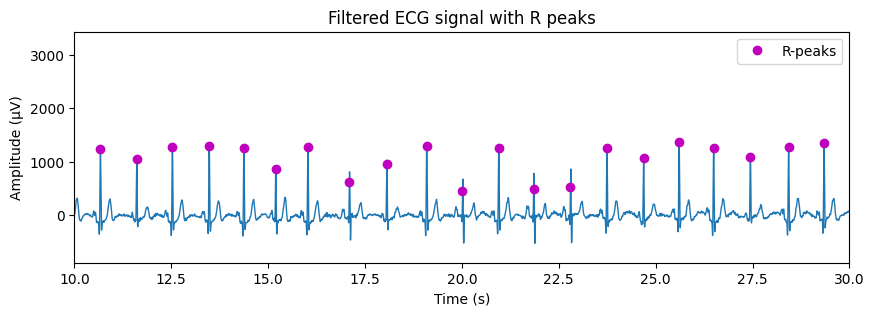

In [27]:
# Plots showing respectively the raw ECG signal with annotated R-peaks and the ECG signal after Wiener filtering with annotated R-peaks

# plot 20s original
fig, ax = plt.subplots(figsize=(10,3))
start_time = 10
end_time = 30
# raw ECG signal
plot_ecg_time(ecg, fs, ax)
# annotated R-peaks
mask = (peaks_raw/fs >= start_time) & (peaks_raw/fs <= end_time)
ax.plot(peaks_raw[mask] / fs, ecg[peaks_raw[mask]], 'ro', markersize=6, label="R-peaks")

ax.set_xlim([start_time, end_time])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title("Raw, unfiltered ECG signal with R peaks")
ax.legend()
plt.show()

# plot 20s filtered
fig, ax = plt.subplots(figsize=(10,3))
start_time = 10
end_time = 30
# raw ECG signal
plot_ecg_time(sig_wi, fs, ax)
# annotated R-peaks
mask_f = (peaks_filt/fs >= start_time) & (peaks_filt/fs <= end_time)
ax.plot(peaks_filt[mask_f] / fs, sig_wi[peaks_filt[mask_f]], 'mo', markersize=6, label="R-peaks")

ax.set_xlim([start_time, end_time])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title("Filtered ECG signal with R peaks")
ax.legend()
plt.show()

Peaks after Butterworth: 674


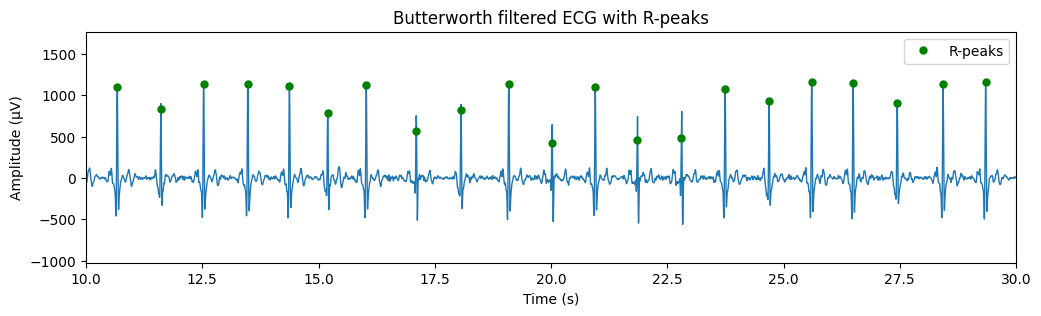

In [28]:
b, a = scipy.signal.butter(3, [5/(fs/2), 40/(fs/2)], btype='band')
sig_butter = scipy.signal.filtfilt(b, a, sig_wi)

peaks_butter = pan_tompkins(sig_butter, show=False)
print("Peaks after Butterworth:", len(peaks_butter))

fig, ax = plt.subplots(figsize=(12, 3))

plot_ecg_time(sig_butter, fs, ax)

mask_b = (peaks_butter/fs >= start_time) & (peaks_butter/fs <= end_time)
ax.plot(peaks_butter[mask_b] / fs,
        sig_butter[peaks_butter[mask_b]],
        'go', markersize=5, label="R-peaks")

ax.set_xlim([start_time, end_time])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title("Butterworth filtered ECG with R-peaks")
ax.legend()
plt.show()

#### 1.2.3 Additional questions


1.   Assuming independent additive noise, should you consider the average PQRST-complex as a template for the clean signal, or as a template for the signal with noise? Why?
- It should be considered as a template for the clean signal. Because under the assumption of independent additive noise, each measured hearbeat can be written as x_i[t] = s[t] + n_i[t], where s[t] is the true PQRST waveform and n_i[t] the zero mean noise that varies from beat to beat. When multiple PQRST complexes are aligned and averaged, the noise terms tend to cancel out while the signal component is preserved. Thus, the average PQRST complex is a noise reduced estimate of the clean ECG signal, and is the template for the clean signal.

2.  Should you remove the mean from the PQRST-complexes before averaging them? What about the mean of the noise segments?
- Yes, the mean should be removed in both cases. Removing the mean before PSD estimation avoids the dominance of the DC component which does not carry useful information about ECG morphology. Since the PQRST complex is transient and oscillatory, its mean does not represent a physiological feature and would otherwise bias the PSF toward low frequencies.
Moreover, the noise is typically assumed to be zero mean in wiener filtering theory. So removing the mean from noise segments will ensure that the noise PSD reflects fluctations rather than baseline offsets.

3.   Which method and parameters did you choose to estimate the PSD’s? Why?
- The method chosen is the Welch's method for PSD estimation, and the parameters are Hann window, segment length of L/2= samples, overlap of 50% and FFT length L=256. Welch’s method provides a good trade-off between frequency resolution and variance reduction by averaging periodograms computed from overlapping, windowed segments. Compared to a simple periodogram, Welch PSD estimates are smoother and more robust to noise, which is important when constructing a Wiener filter.
The chosen segment length is short enough to assume approximate stationarity of the ECG and noise, while the FFT length provides sufficient frequency resolution for ECG signals.

4.   Do you see any edge effects after filtering? Why (not)?
- I do not see any significant egde effects.

#### 1.2.4 Deliverables


*   A plot that shows the average PQRST-complex in the time domain.
*   Three plots that respectively show the PSD of the average PQRST-complex, the PSD of the noise and the transfer function of the Wiener filter (all in dB).
*   Two plots showing respectively the raw ECG signal with annotated R-peaks and the ECG signal after Wiener filtering with annotated R-peaks. Plot the same 20s window of the ECG signal in both plots. If you add an additional Butterworth filter after the Wiener filter, you should add a third plot with annotated R-peaks showing the same 20s window of the filtered ECG signal after Butterworth filtering.

### 1.3 Segmentation

Split the filtered ECG signal into small segments of equal length, such that each segment contains a single heartbeat (i.e. a single PQRST-complex). Once again, you can assume that a PQRSTcomplex starts 0.3 s before the R-peak and ends 0.4 s after the R-peak. You can discard all samples that do not fall within any PQRST-complex. All segments should thus be 0.7 s long. Also segment
the per-sample ground-truth labels, such that each segment has a single label indicating from which subject the PQRST-complex was recorded. Take majority vote if multiple labels present for one segment.

You may remove a few segments (up to 10 in total) at the edges of the signal if you deem them to be too distorted by the edge effects of the filtering.

Once the signal is segmented, compute the average ECG segment belonging to subjects 1, 2, 3, 4 and 5 separately. Also, compute what percentage of segments belong to each of the five subjects. You can use the ground-truth labels to do this. These averages and percentages are merely created for visualisation and will not be used further in the project.

In [29]:
# split the filtered ECG signal into small segments
# segment the labels as well (take majority vote if multiple labels present for 1 segment)

# we segment the last filtered signal
signal_to_segment = sig_butter   # or sig_wi
current_peaks = pan_tompkins(signal_to_segment, show=False)

pre = int(0.3 * fs)
post = int(0.4 * fs)
seg_len = pre + post

segmented_ecg = []
segmented_labels = []

for p in current_peaks:
    start = p - pre
    end = p + post

    if start < 0 or end > len(signal_to_segment):
        continue

    ecg_seg = signal_to_segment[start:end]
    lab_seg = labels[start:end]

    if len(ecg_seg) == seg_len:
        segmented_ecg.append(ecg_seg)
        segmented_labels.append(
            Counter(lab_seg).most_common(1)[0][0]   # majority vote
        )

segmented_ecg = np.asarray(segmented_ecg)
segmented_labels = np.asarray(segmented_labels)

print(f"Total segmented ECG complexes: {len(segmented_ecg)}")
print("Segment shape:", segmented_ecg.shape)
print("Labels shape:", segmented_labels.shape)


Total segmented ECG complexes: 674
Segment shape: (674, 140)
Labels shape: (674,)


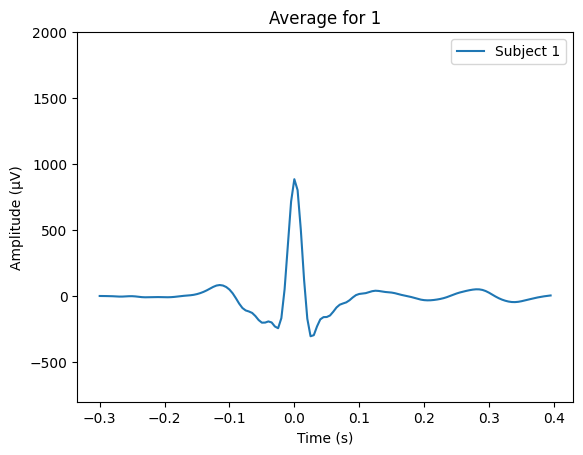

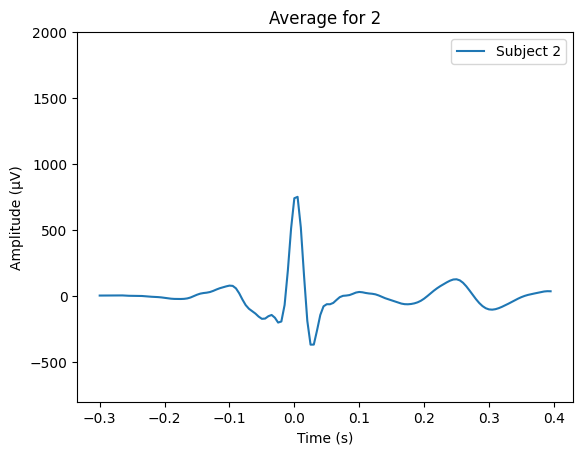

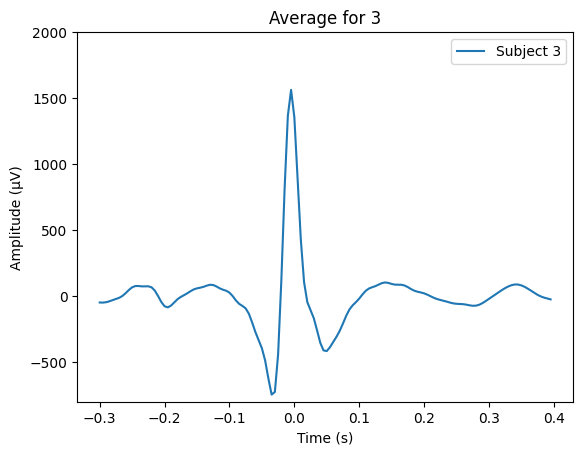

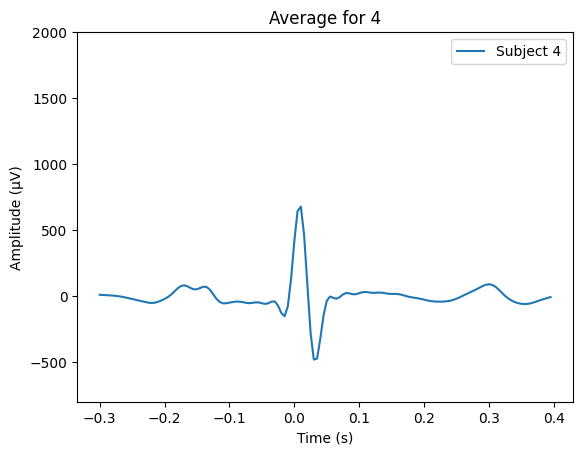

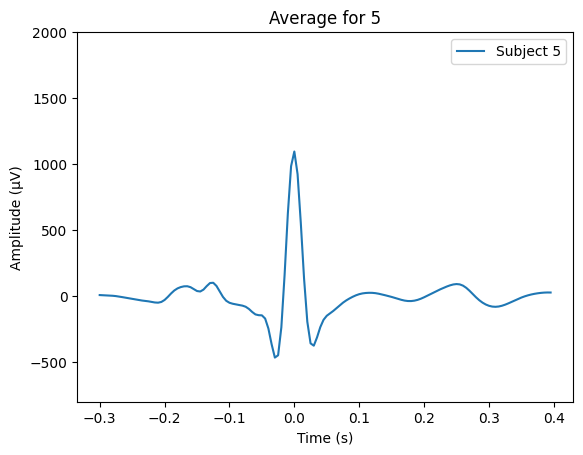

In [30]:
# plot avg PQRST for each individual

t = np.arange(segmented_ecg.shape[1]) / fs - 0.3  # time relative to R-peak

for i in range(5):
    fig, ax = plt.subplots()

    subject_segments = segmented_ecg[segmented_labels == (i + 1)]

    if len(subject_segments) > 0:
        avg_pqrst = np.mean(subject_segments, axis=0)

        ax.plot(t, avg_pqrst, label=f"Subject {i+1}")

    ax.set_ylim([-800, 2000])
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title(f"Average for {i+1}")
    ax.legend()
    plt.show()



In [31]:
# showing the percentage of segments belonging to each of the five subjects
unique_labels, counts = np.unique(segmented_labels, return_counts=True)
percentages = 100 * counts / len(segmented_labels)

print("Percentage of segments per subject:")
df = pd.DataFrame({
    "Subject": unique_labels,
    "Count": counts,
    "Percentage (%)": percentages
})
df.set_index("Subject", inplace=True)
df

Percentage of segments per subject:


,Count,Percentage (%)
Subject,,
1,118,17.507418
2,147,21.810089
3,40,5.934718
4,111,16.468843
5,258,38.278932


#### 1.3.1 Additional questions
1.   Do you see any defining differences between the average PQRST-complex of each subject?
- Yes, there are clear differences between the average PQRST-complexes of the subjects. Although all waveforms share the same overall structure and are well aligned at the R-peak, they differ in QRS amplitude, width, and shape, as well as in the morphology of the surrounding waves. In particular, subject 3 shows a noticeably higher R-peak and deeper negative deflection compared to the others, while the remaining subjects have more moderate and smoother QRS complexes.


#### 1.3.2 Deliverables
*   Plots containing the average ECG segment of each subject. Make sure that the axes of each plot are equally scaled, such that easy comparison is possible.
*   A table showing the percentage of segments belonging to each of the five subjects.


### 1.4 Wavelet decomposition

Decompose each ECG segment with the Daubechies wavelet of order four using five levels of decomposition. We will use these wavelet decompositions as features for the clustering algorithm.

In [32]:
# The wavelet decomposition of the ECG signal
# Use the Daubechies wavelet of order four (db4) with five levels to decompose the ECG signal

def wavelet_decompose_segments(segments, wavelet="db4", level=5):
  features = []

  for seg in segments:
      coeffs = pywt.wavedec(seg, wavelet=wavelet, level=level)
      features.append(coeffs)

  return features

wavelet_features = wavelet_decompose_segments(
    segmented_ecg,
    wavelet="db4",
    level=5
)

print("Number of segments:", len(wavelet_features))
print("Number of coefficient sets per segment:", len(wavelet_features[0]))


Number of segments: 674
Number of coefficient sets per segment: 6


/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


Select two wavelet coefficients that you consider most important (use the same pair for all segments). Visualize them in a two-dimensional space and color each point according to its ground-truth segment label (hint: use `matplotlib.pyplot.scatter`).




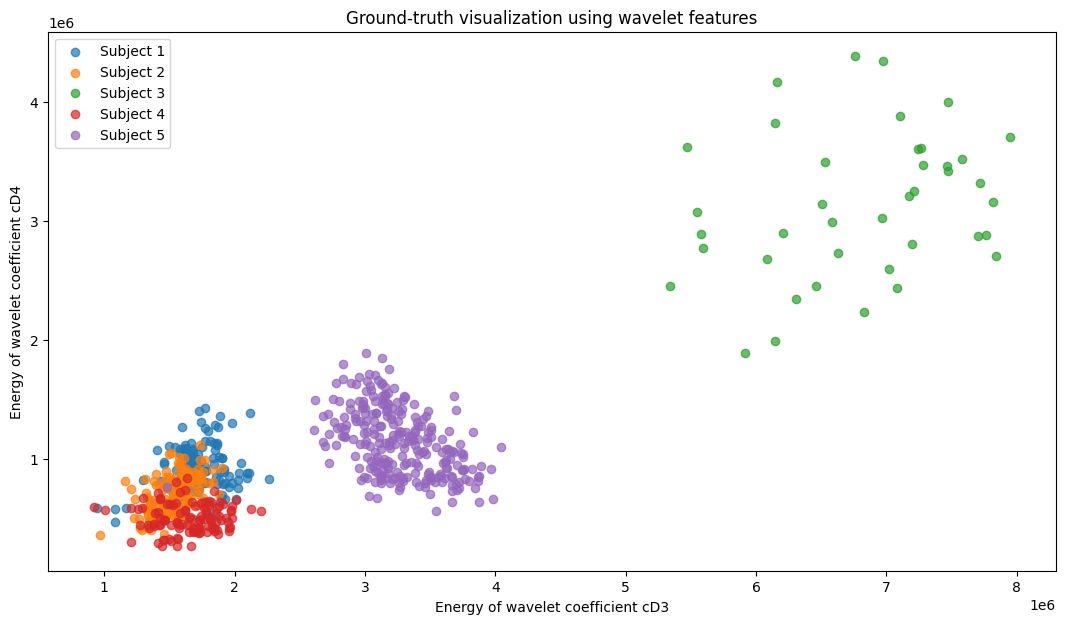

In [33]:
# Choose the two most important wavelet coefficients

features_2d = []

for coeffs in wavelet_features:
    cA5, cD5, cD4, cD3, cD2, cD1 = coeffs
    features_2d.append([
        np.sum(cD3**2),   # energy of cD3
        np.sum(cD4**2)    # energy of cD4
    ])

features_2d = np.array(features_2d)

fig, ax = plt.subplots(figsize=(13, 7))

for cl in range(5):
    idx = segmented_labels == (cl + 1)
    ax.scatter(
        features_2d[idx, 0],
        features_2d[idx, 1],
        label=f"Subject {cl + 1}",
        alpha=0.7
    )

ax.set_xlabel("Energy of wavelet coefficient cD3")
ax.set_ylabel("Energy of wavelet coefficient cD4")
ax.set_title("Ground-truth visualization using wavelet features")
ax.legend()
plt.show()

#### 1.4.1 Additional questions

*   What is the advantage of this wavelet decomposition before clustering, compared to simply clustering the ECG segments directly?
    - Wavelet decomposition summarizes each ECG segment into a small number of meaningful features that describe the shape and structure of the heartbeat. This reduces noise and avoids problems caused by small timing differences between beats. As a result, clustering becomes easier and more reliable than when using the raw ECG segments, which are long, noisy, and difficult to compare directly.


#### 1.4.2 Deliverable
*   A plot visualising the ground-truth labels using the two most important wavelet coefficients.

### 1.5 K-means clustering

Cluster the wavelet coefficients using K-means clustering. Assign each cluster to a subject. Compute the confusion matrix and average accuracy of the clustering. If you notice that the names of the clusters don’t properly match the names of the subject (e.g. if the ECG segments of subject 1 correspond to cluster 2, rather than cluster 1), you can use the provided function `match_labels` to automatically correct this. Make sure you understand what the function does if you use it.

Visualise the clustering result in a two-dimensional space using the selected two most important wavelet coefficients from 1.4. Colour the clusters with the **predicted** cluster labels.

In [34]:
# help function match_labels
from itertools import permutations
def match_labels(ground_truth_labels, predicted_labels):
    """
    Match predicted cluster labels to ground-truth labels for best correspondence.

    Parameters
    ----------
    ground_truth_labels : array-like
        Ground-truth labels for each segment.
    predicted_labels : array-like
        Predicted labels for each segment.

    Returns
    -------
    best_match : np.ndarray
        Predicted labels after optimal relabeling.
    best_acc : float
        Accuracy after the optimal relabeling.
    """

    ground_truth_labels = np.asarray(ground_truth_labels).ravel()
    predicted_labels = np.asarray(predicted_labels).ravel()

    assert ground_truth_labels.ndim == 1, \
        "ground_truth_labels should be a vector containing a single label per segment"
    assert predicted_labels.ndim == 1, \
        "predicted_labels should be a vector containing a single label per segment"
    assert len(ground_truth_labels) == len(predicted_labels), \
        "ground_truth_labels and predicted_labels should be equally long"

    true_classes = np.unique(ground_truth_labels)
    predicted_classes = np.unique(predicted_labels)

    assert len(true_classes) == len(predicted_classes), \
        "The number of different classes is different in the ground truth and predicted"

    best_acc = 0.0
    best_match = predicted_labels.copy()

    for match_order in permutations(true_classes):
        new_predicted = predicted_labels.copy()
        for j, pred_class in enumerate(predicted_classes):
            new_predicted[predicted_labels == pred_class] = match_order[j]
        acc = np.mean(new_predicted == ground_truth_labels)
        if acc > best_acc:
            best_acc = acc
            best_match = new_predicted.copy()

    return best_match, best_acc

Accuracy after matching: 0.558


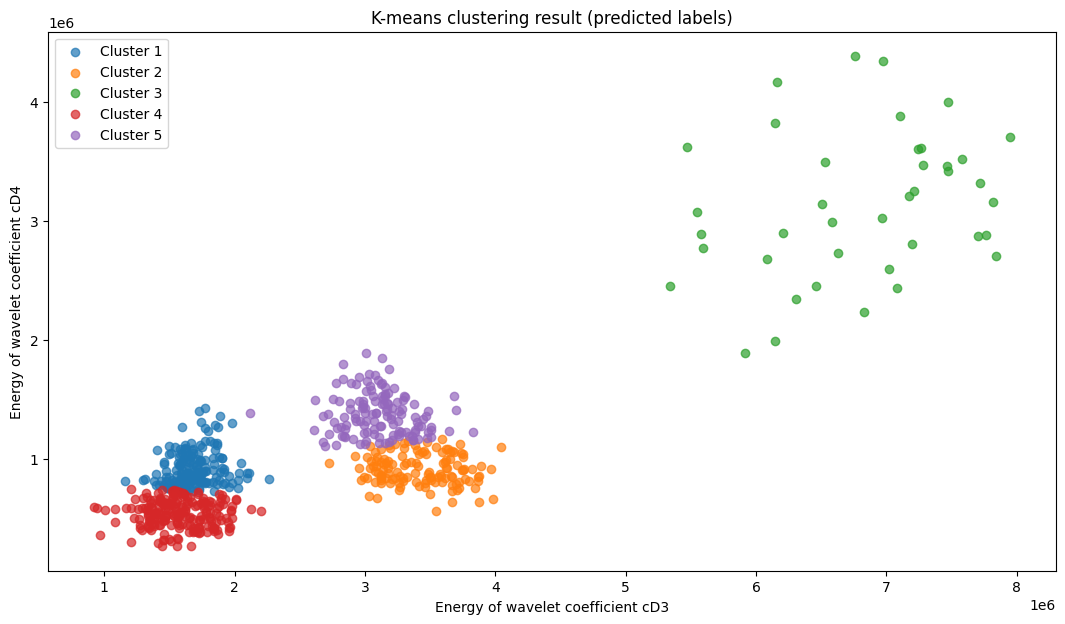

In [35]:
# Cluster the wavelet coefficients using K-means clustering
# Create the K-means algorithm object, with k=5 clusters

X = features_2d # shape (n_segments, 2)
y_true = segmented_labels

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")

# Get the cluster indices ("Which data point belongs to which cluster?")
y_pred = kmeans.fit_predict(X_norm)

# Get the cluster centroids
centroids = kmeans.cluster_centers_

y_pred_matched, acc = match_labels(y_true, y_pred)
print(f"Accuracy after matching: {acc:.3f}")

# Visualise the clustering result in a two-dimensional space using
# two wavelet coefficients that are highly representative
fig, ax = plt.subplots(figsize=(13, 7))

for cl in range(5):
    idx = y_pred_matched == (cl + 1)
    ax.scatter(
        X[idx, 0],
        X[idx, 1],
        label=f"Cluster {cl + 1}",
        alpha=0.7
    )

ax.set_xlabel("Energy of wavelet coefficient cD3")
ax.set_ylabel("Energy of wavelet coefficient cD4")
ax.set_title("K-means clustering result (predicted labels)")
ax.legend()
plt.show()

In [36]:
from sklearn.metrics import confusion_matrix

# compute and print the confusion matrix
cm = confusion_matrix(y_true, y_pred_matched)
print("Confusion matrix:")
print(cm)

Confusion matrix:
[[100   0   0  17   1]
 [ 61   0   0  86   0]
 [  0   0  40   0   0]
 [  4   0   0 107   0]
 [  1 128   0   0 129]]


#### 1.5.1 Additional questions

*   Is the result of the unsupervised clustering always the same? Why (not)?
      - No, because for example in our case, when using K-means, the algorithm depends on random initialization of cluster centroids. Different initializations can lead to different local minima, especially when clusters overlap.
*   Why do the names of the cluster labels not always match the names of the class labels?
    - Cluster labels are assigned arbitrarily by K-means and have no particular meaning. The numbering of clusters does not correspond to subject labels, so a relabeling step is needed to match clusters to the ground-truth classes.
*   Is it a good idea to normalise the wavelets before classification? Why (not)?
    - Yes, because normalization ensures that all wavelet features contribute equally to distance based algorithms like K-means. Without normalization, features with larger numerical ranges may dominate the clustering.
*   How do you decide which wavelet values are the most relevant to model the ECG segments? Why?
    - I chose the wavelet coefficients based on their ability to capture important ECG characteristics, such as the QRS complex and overall morphology.

#### 1.5.2 Deliverables
*   A plot visualising the predicted cluster labels using the two most important wavelet coefficients.
*   The confusion matrix.


### 1.6 Dimensionality reduction

#### 1.6.1 Dimensionality reduction and clustering

Reduce the dimensionality of the wavelet features as much as possible without dramatically reducing the performance of your algorithm. You can use any method you know to get the number of dimensions as low as possible. After dimensionality reduction, cluster the features again using K-means.

Similar to Section 1.5, compute the accuracy and confusion matrix and visualise the ground-truth labels and predicted cluster labels in a two-dimensional space. Pick two relevant dimensions after dimensionality reduction to visualise the result. Also, provide a table comparing the accuracy of the model before and after dimensionality reduction.

In [37]:
# Consider whether normalization is necessary before dimensionality reduction

X_full = [] # the full wavelet energy feature matrix

for coeffs in wavelet_features:
    # coeffs = [cA5, cD5, cD4, cD3, cD2, cD1]
    energies = [np.sum(coeff**2) for coeff in coeffs]
    X_full.append(energies)

X_full  = np.array(X_full)
print("Shape of the wavelet energy feature matrix", X_full.shape)
y_true = segmented_labels

scaler = StandardScaler() # normalization BEFORE dim. reduction
X_full_norm = scaler.fit_transform(X_full)

# Decide the number of dimensions to be kept
# N = ...
pca_full = PCA()
pca_full.fit(X_full_norm)

explained_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(explained_var >= 0.9) +1
print("Explained variance", explained_var)
print("Number of components to reach above 90% variance:", n_components)
N = n_components # 2

# Reduce the dimensionality of the coefficients
pca = PCA(n_components=N)
X_PCA = pca.fit_transform(X_full_norm)

# Consider whether normalization is necessary after* dimensionality reduction
# not necessary


Shape of the wavelet energy feature matrix (674, 6)
Explained variance [0.60785747 0.80917562 0.93115109 0.96213926 0.98954949 1.        ]
Number of components to reach above 90% variance: 3


Accuracy after dimensionality reduction: 0.773
Confusion matrix after dimensionality reduction:
[[  1 105   0   0  12]
 [  0 120   0  25   2]
 [  0   0  40   0   0]
 [  2   3   0 106   0]
 [  2   2   0   0 254]]


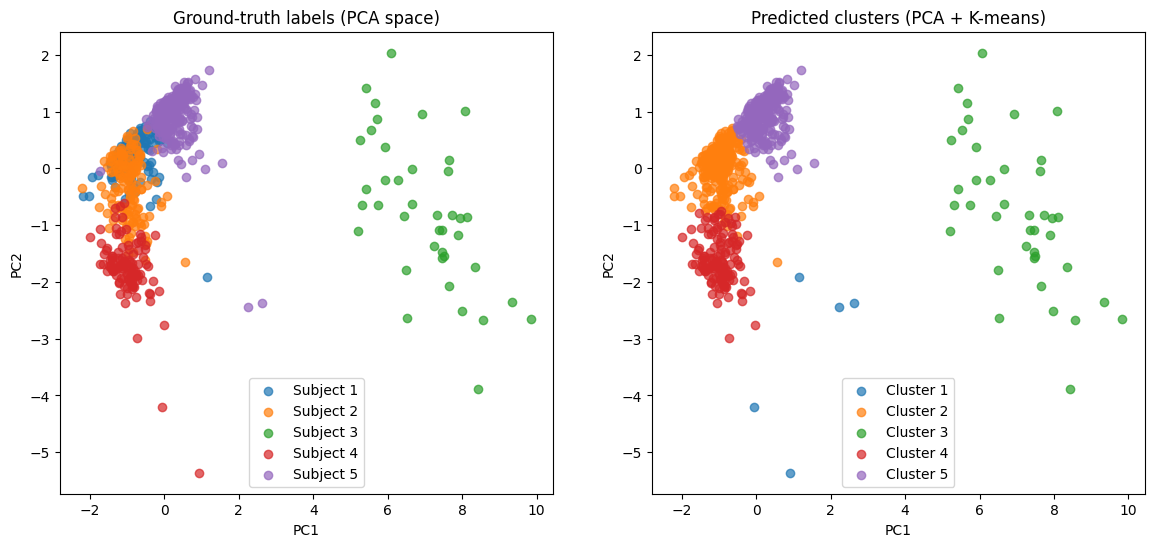

In [38]:
# Perform K-means clustering
# ...
kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
y_pred_pca = kmeans.fit_predict(X_PCA)

y_pred_pca_matched, acc_after = match_labels(y_true, y_pred_pca)
print(f"Accuracy after dimensionality reduction: {acc_after:.3f}")

cm_pca = confusion_matrix(y_true, y_pred_pca_matched)
print("Confusion matrix after dimensionality reduction:")
print(cm_pca)

# Visualize the ground-truth labels and predicted cluster labels
# Consider carefully which dimensions after dimensionality reduction are
# more relevant for this classification problem

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

for cl in range(5):
    idx = y_true == (cl + 1)
    axs[0].scatter(X_PCA[idx, 0], X_PCA[idx, 1], label=f"Subject {cl+1}", alpha=0.7)
axs[0].set_title("Ground-truth labels (PCA space)")
axs[0].set_xlabel("PC1")
axs[0].set_ylabel("PC2")
axs[0].legend()

for cl in range(5):
    idx = y_pred_pca_matched == (cl + 1)
    axs[1].scatter(X_PCA[idx, 0], X_PCA[idx, 1], label=f"Cluster {cl+1}", alpha=0.7)
axs[1].set_title("Predicted clusters (PCA + K-means)")
axs[1].set_xlabel("PC1")
axs[1].set_ylabel("PC2")
axs[1].legend()

plt.show()



In [39]:
# accuracy comparison table
acc_before = acc
acc_table = pd.DataFrame({
    "Method": ["Before dimensionality reduction", "After dimensionality reduction with PCA"],
    "Accuracy": [acc_before, acc_after]
})

print(acc_table)

                                    Method  Accuracy
0          Before dimensionality reduction  0.557864
1  After dimensionality reduction with PCA  0.772997


#### 1.6.2 Additional questions
*   Should you normalise before dimensionality reduction? What about after dimensionality reduction?
    - Yes, normalization should be performed before dimensionality reduction, because PCA is sensitive to feature scale and would otherwise be dominated by high-variance features. Normalization after dimensionality reduction is optional, but can be useful to ensure balanced distances when applying K-means clustering.

#### 1.6.3 Deliverables
*   The confusion matrix.
*   A plot visualising the ground-truth labels and predicted cluster labels using the two most important dimensions.
*   A table comparing the accuracy of the clustering before and after the dimensionality reduction.